# 02 — Station map, Palermo survival comparison, and renewal-chain toy figure

Produces:
- `figures/map_palermo.pdf` (Fig. 1)
- `figures/PALERMO_comparison_dry_spell_egpd_geom_4seasons.pdf` (Fig. 2)
- `figures/toy_data_fig_with_N.pdf` (Fig. 3)

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parents[1]))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from article_code.util_files import config, plotting
# from article_code.util_files import spell_models as sm

NAME_STATION_EXAMPLE = config.STATION_EXAMPLE
# Load dry-spell durations for Palermo from the JSON exported by notebook 01.
base_filename = f"ecad_data_south_europe_filtered_after_{config.START_YEAR}_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)


## Fig. 1 - Map of southern-Europe ECAD stations, Palermo highlighted

In [2]:
stations = pd.read_csv(config.STATION_METADATA_CSV)
list_cities = sorted(spells.keys())
stations_used = stations[stations.city.isin(list_cities)]
mask_palermo = stations['city'].str.upper().str.contains(NAME_STATION_EXAMPLE, na=False)

fig_map = go.Figure()
fig_map.add_trace(go.Scattergeo(
    lon=stations_used.loc[~mask_palermo, 'lon'],
    lat=stations_used.loc[~mask_palermo, 'lat'],
    mode='markers', marker=dict(size=4, color='black'),
    name='stations'))
fig_map.add_trace(go.Scattergeo(
    lon=stations_used.loc[mask_palermo, 'lon'],
    lat=stations_used.loc[mask_palermo, 'lat'],
    mode='markers', marker=dict(size=10, color='orange'),
    name='Palermo'))
fig_map.update_geos(showcountries=True,showland=True,landcolor="lightgray",
                    lataxis_range=[34, 46], lonaxis_range=[-10, 30])
fig_map.update_layout(width=900, height=500, margin=dict(l=0, r=0, t=0, b=0))

plotting.save_map_palermo(fig_map)

WindowsPath('C:/Users/antoi/Desktop/code/companion_code_article/figures/PALERMO/map_palermo.pdf')

## Fig. 2 - Dry-spell survival in Palermo (empirical vs. geometric vs. hdeGPD) across seasons

In [3]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parents[1]))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from article_code.util_files import config, plotting
from article_code.util_files.spell_models import *
NAME_STATION_EXAMPLE = config.STATION_EXAMPLE

# Load saved results from notebook 01.
name_folder_save_results = (f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}")
path_folder_save_results = config.RESULTS_FIT_DIR / name_folder_save_results
path_mixt_geom_fit_wet_spells = path_folder_save_results / "wet_spell_fit_mixt_geomresult_fit_parameters.csv"
pth_hdegpd_fit_dry_spells = path_folder_save_results / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv"
df_fit_wet = pd.read_csv(path_mixt_geom_fit_wet_spells)
df_fit_dry = pd.read_csv(pth_hdegpd_fit_dry_spells)
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s:s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s:s.split()[-1])
# Load dry-spell durations for Palermo from the JSON exported by notebook 01.
with open(config.EXPORTS_JSON_DIR / 
          f'ecad_data_south_europe_filtered_after_1946_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json') as fh:
    spells = json.load(fh)
palermo_spells = spells[NAME_STATION_EXAMPLE]['dry_spell']['duration_spell']
palermo_dates = spells[NAME_STATION_EXAMPLE]['dry_spell']['start_date_spell']
palermo_months = np.array([str(s)[4:6] for s in palermo_dates])

WindowsPath('C:/Users/antoi/Desktop/code/companion_code_article/figures/PALERMO/PALERMO_comparison_dry_spell_egpd_geom_4seasons.pdf')

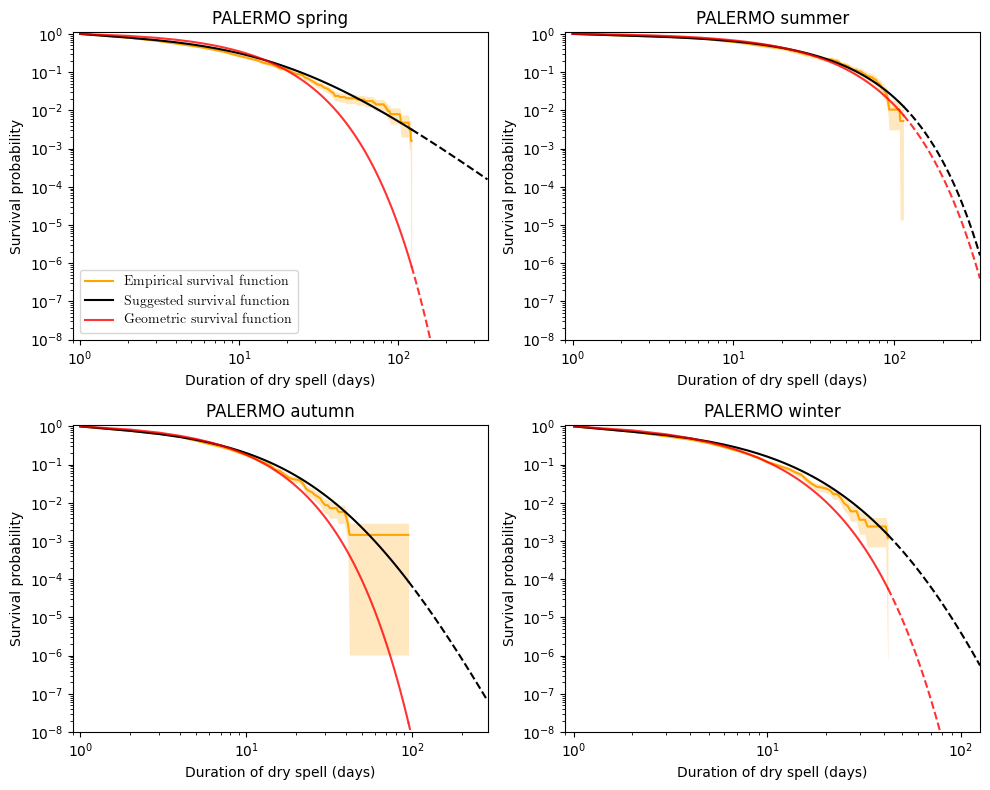

In [4]:
level_quant = 0.95
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
for ax, vec_month_seasons in zip(axes.flat, config.LIST_MONTH_SEASONS[1:]):
    season = vec_month_seasons[3]
    month_set = set(vec_month_seasons)
    season_mask = np.array([m in month_set for m in palermo_months])
    concatenation_neg_exc = np.array(palermo_spells)[season_mask]

    # Fit parameters for this season
    row = df_fit_dry[(df_fit_dry['city'].str.upper() == NAME_STATION_EXAMPLE) &
                     (df_fit_dry['season'] == season)].iloc[0]
    cdf_egpd = make_cdf_fitted_hdeGPD_from_params(
        f_1=row['f_1'], xi_gpd=row['xi'],
        sigma_gpd=row['sigma'], kappa_gpd=row['kappa'])

    # x ranges (observed and extension to 3 * max)
    min_season = int(np.min(concatenation_neg_exc))
    max_season = int(np.max(concatenation_neg_exc))
    x_min_plot = max(1, min_season)
    x_full = np.arange(x_min_plot, max_season + 1)
    x_ext  = np.arange(max_season, 3 * max_season + 1)

    # Empirical survival + standard errors
    f_emp_array        = np.array([S_hat(concatenation_neg_exc, int(x))[0] for x in x_full])
    errors_f_emp_array = np.array([S_hat(concatenation_neg_exc, int(x))[1] for x in x_full])

    # Geometric MLE -> survival
    p_geom = fit_geometric_p_mle(concatenation_neg_exc)
    q_leave = 1 - p_geom

    left_x = x_min_plot

    # Empirical
    ax.plot(x_full, f_emp_array,
            label="Empirical survival function", color="orange")

    # Suggested (hdeGPD) — solid on observed range, dashed on extension
    ax.plot(x_full, [1 - cdf_egpd(int(x) - 1) for x in x_full],
            label="Suggested survival function", color="black")
    ax.plot(x_ext, [1 - cdf_egpd(int(x) - 1) for x in x_ext],
            linestyle="dashed", color="black")

    # Geometric — solid on observed range, dashed on extension
    ax.plot(x_full, [q_leave ** (int(x) - 1) for x in x_full],
            label="Geometric survival function", color="red", alpha=0.8)
    ax.plot(x_ext, [q_leave ** (int(x) - 1) for x in x_ext],
            linestyle="dashed", color="red", alpha=0.8)

    # Empirical error band
    mask = x_full >= left_x
    ax.fill_between(
        x_full[mask],
        (f_emp_array - errors_f_emp_array)[mask],
        (f_emp_array + errors_f_emp_array)[mask],
        alpha=0.25, linewidth=0.1, color="orange",
    )

    ax.set_title(f"{NAME_STATION_EXAMPLE} {season}")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlabel("Duration of dry spell (days)")
    ax.set_ylabel("Survival probability")
    ax.set_xlim((max(0.9 * left_x, 0.9), int(3 * max_season)))
    ax.set_ylim((1e-8, 1.1))
    if season == "spring":
        ax.legend()

fig.tight_layout()
plotting.save_palermo_survival_overlay(fig)